# Logjam — Worked Examples

This notebook mirrors the worked examples in the [Logjam README](https://github.com/mgkay/Logjam). Examples are ordered for incremental capability building — each one introduces a focused set of Logjam functions that later examples build upon. The full capability set is described in the README overview.

**Examples:**
1. [Spatial Data](#example-1--spatial-data)
2. [Mapping](#example-2--mapping)
3. [Facility Location](#example-3--facility-location)
4. [Network Analysis and Vehicle Routing](#example-4--network-analysis-and-vehicle-routing)
5. [Vehicle Routing (OSM Network)](#example-5--vehicle-routing-osm-network)

In [1]:
# Activate the local Logjam development environment
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

  Activating project at `c:\Users\kay\Documents\cdev\log\Logjam`


---

## Example 1 — Spatial Data

Logjam includes a built-in U.S. gazetteer covering cities (`usplace`), counties (`uscounty`), 3- and 5-digit ZIP codes (`uszcta3`, `uszcta5`), CBSAs (`uscbsa`), and CSAs (`uscsa`). All tables share a consistent schema: FIPS codes for joining, LON/LAT coordinates following the Logjam convention (longitude first), and population counts where available. This example demonstrates loading and filtering place data, FIPS code conversion, and geographic name lookup.

In [2]:
using Logjam
using DataFrames

# Load U.S. place data (cities, towns, CDPs) and inspect the schema
places = usplace()
display(first(places[:, [:NAME, :ST, :LON, :LAT, :POP, :ISCUS]], 4))

Row,NAME,ST,LON,LAT,POP,ISCUS
,String,Symbol,Float64,Float64,Int64,Bool
1,Albertville,AL,-86.2107,34.2631,22386,true
2,Alexander City,AL,-85.9371,32.9272,14843,true
3,Anniston,AL,-85.8109,33.6735,21564,true
4,Auburn,AL,-85.4895,32.6077,76143,true


In [3]:
# FIPS conversion: state symbol ↔ FIPS code
fips_nc = st2fips(:NC)           # 37
sym_nc  = fips2st(fips_nc)       # :NC

# Filter to NC cities with population over 100,000
nc_large = filter(r -> r.STFIP == fips_nc && r.POP > 100_000, places)
println("$(nrow(nc_large)) NC cities with pop > 100k")

# Forward geocoding: city name to coordinates
raleigh_xy = name2lonlat("Raleigh, NC", places)   # [-78.64, 35.78]

# Reverse geocoding: coordinates to nearest named place
nearest = lonlat2name([-78.85 35.73], filter(r -> r.POP > 50_000 && r.ISCUS, places))
println("Nearest large city: $(nearest.name[1]) ($(round(nearest.dist[1]; digits=1)) mi)")

# Load continental US 3-digit ZIP centroids
z3 = filter(r -> r.ISCUS, uszcta3())
println("Continental US 3-digit ZIPs: $(nrow(z3))")

10 NC cities with pop > 100k
Nearest large city: Apex (1.3 mi)
Continental US 3-digit ZIPs: 882


**After-action.** The `ISCUS` flag is the standard filter for continental U.S. analysis — it removes Alaska, Hawaii, Puerto Rico, and other territories that would distort national maps. All coordinate columns follow the (LON, LAT) convention throughout Logjam, which means western longitudes are negative. The `st2fips` and `fips2st` functions enable joins between datasets that use different geographic identifiers. `lonlat2name` is used in later examples to reverse-geocode facility hub coordinates into interpretable city names, making model outputs readable without manual lookup. The `name2lonlat` function provides the inverse operation when building scenarios from named locations.

---

## Example 2 — Mapping

Logjam's `makemap` function creates GeoMakie map figures with automatic projection, region detection, and a FAF5 interstate highway background. This example maps NC cities and introduces the full mapping toolkit: `makemap` for the figure and axis, `scatter!` and `text!` for data, `aligntext` for automatic label positioning, and the `hborders` return value for customizing the built-in road overlay.

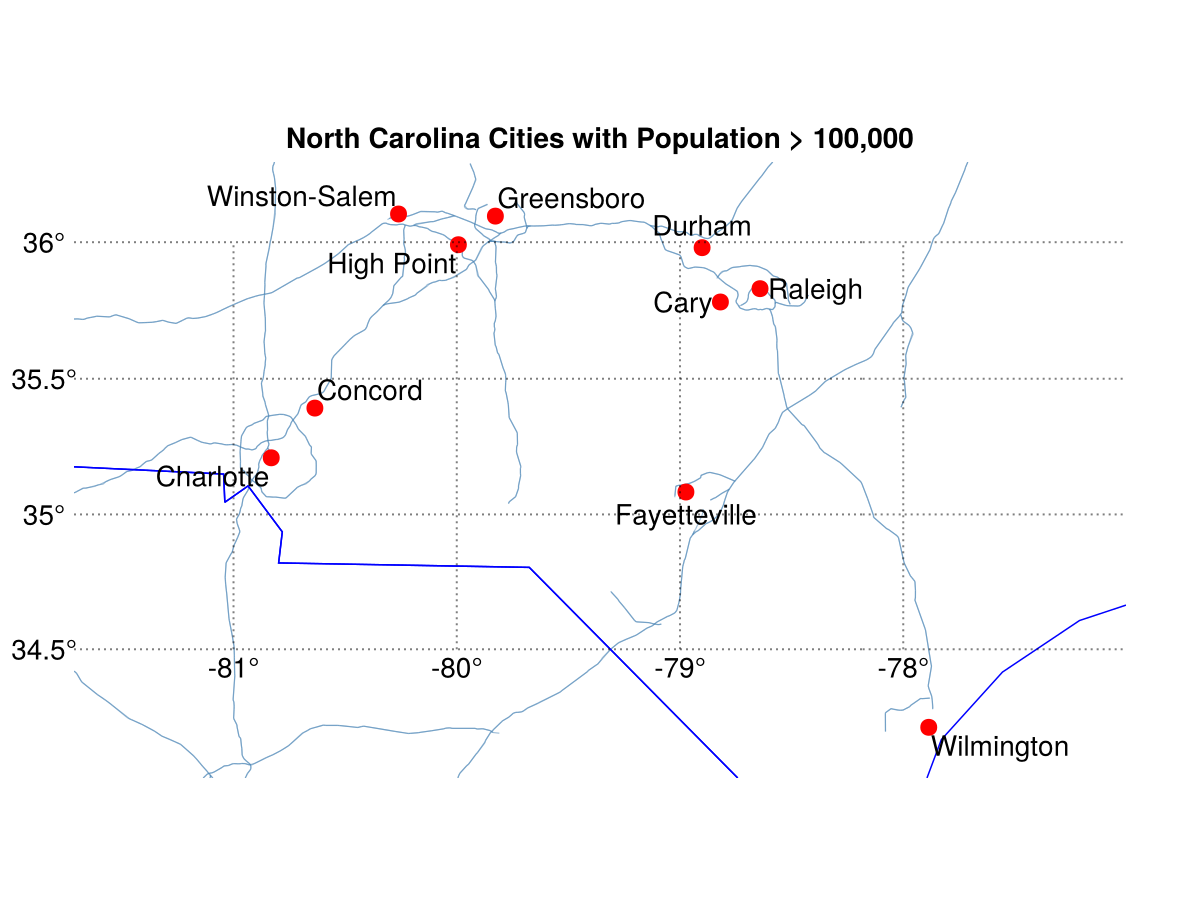

CairoMakie.Screen{IMAGE}


In [4]:
using Logjam
using GeoMakie, CairoMakie, DataFrames

# Load NC cities with population > 100,000
cities = filter(r -> r.STFIP == st2fips(:NC) && r.POP > 100_000, usplace())
x, y, name = cities.LON, cities.LAT, cities.NAME

# Create map — auto-fits region to data; draws FAF5 interstates by default.
# Returns: fig (Figure), ax (GeoAxis), hborders (road/border handles), limits (bbox).
fig, ax, hborders, limits = makemap(x, y)
ax.title = "North Carolina Cities with Population > 100,000"

# Customize the built-in interstate overlay (hborders[1])
hborders[1].color[] = (:steelblue, 0.5)

# Plot city locations and labels
scatter!(ax, x, y, color=:red, markersize=12)
text!(ax, x, y, text=name; aligntext(x, y)...)

display(fig)

**After-action.** `makemap` detects when coordinates fall within the continental U.S. and automatically overlays the FAF5 interstate network as a geographic reference. The `hborders` return value exposes the road and border line handles for post-hoc styling, as shown above for the interstate color. `aligntext(x, y)` returns a named tuple of keyword arguments (`:align`, `:offset`) that are splatted into `text!` via `...`, automatically positioning each label to avoid overlap with its marker.

---

## Example 3 — Facility Location

A classic strategic logistics problem: place a fixed number of distribution hubs to minimize total weighted distance to customers. Using U.S. 3-digit ZIP code centroids as demand points and population as demand weight, the *p*-median model selects six hubs that minimize total people-miles. This example introduces `dists` for distance matrix construction and `pmedian`, `alloclines`, and `lonlat2name` for the full facility location workflow.

In [5]:
using Logjam
using GeoMakie, CairoMakie, DataFrames

# Load continental US 3-digit ZIP code centroids
z3 = filter(r -> r.ISCUS, uszcta3())
XY = hcat(z3.LON, z3.LAT)

# Build population-weighted cost matrix: C[i,j] = distance(i,j) × population(j)
C = dists(XY, XY, :mi) .* z3.POP'

882×882 Matrix{Float64}:
 0.0        1.27581e6  4.80354e6  2.18512e6  …  9.2409e8   4.91286e7
 3.51217e6  0.0        5.41746e6  2.77588e6     9.257e8    4.92168e7
 1.77188e7  7.25901e6  0.0        3.21568e6     9.08958e8  4.8294e7
 1.24675e7  5.75327e6  4.974e6    0.0           9.21586e8  4.89931e7
 2.25424e7  8.77433e6  9.50444e6  2.97611e6     9.3507e8   4.97385e7
 1.87714e7  6.75069e6  9.60909e6  3.61903e6  …  9.38799e8  4.99417e7
 1.85466e7  6.78733e6  9.43232e6  3.40518e6     9.3798e8   4.98968e7
 2.73191e7  9.9899e6   1.16637e7  4.61751e6     9.44071e8  5.0234e7
 3.57961e7  1.33727e7  1.33056e7  5.41801e6     9.45415e8  5.0311e7
 4.18636e7  1.54333e7  1.51848e7  6.66314e6     9.51715e8  5.06587e7
 3.45029e7  1.23299e7  1.3883e7   6.19699e6  …  9.51841e8  5.06621e7
 3.6616e7   1.33181e7  1.4167e7   6.16469e6     9.5125e8   5.0631e7
 3.60784e7  1.31345e7  1.40081e7  6.05778e6     9.50721e8  5.06018e7
 ⋮                                           ⋱  ⋮          
 1.13975e9  4.14776e8 

In [6]:
# Solve p-median: select 6 hubs minimizing total people-miles
y, TC, W = pmedian(6, C; verbose=false)

# Reverse-geocode hub coordinates to nearest large city
hubs = lonlat2name(XY[y, :], filter(r -> r.POP >= 50_000 && r.ISCUS, usplace()))
println("Hub cities: ", join(hubs.name, ", "))

Hub cities: Gary, Warner Robins, Plainfield, Pasadena, Yakima, Dallas


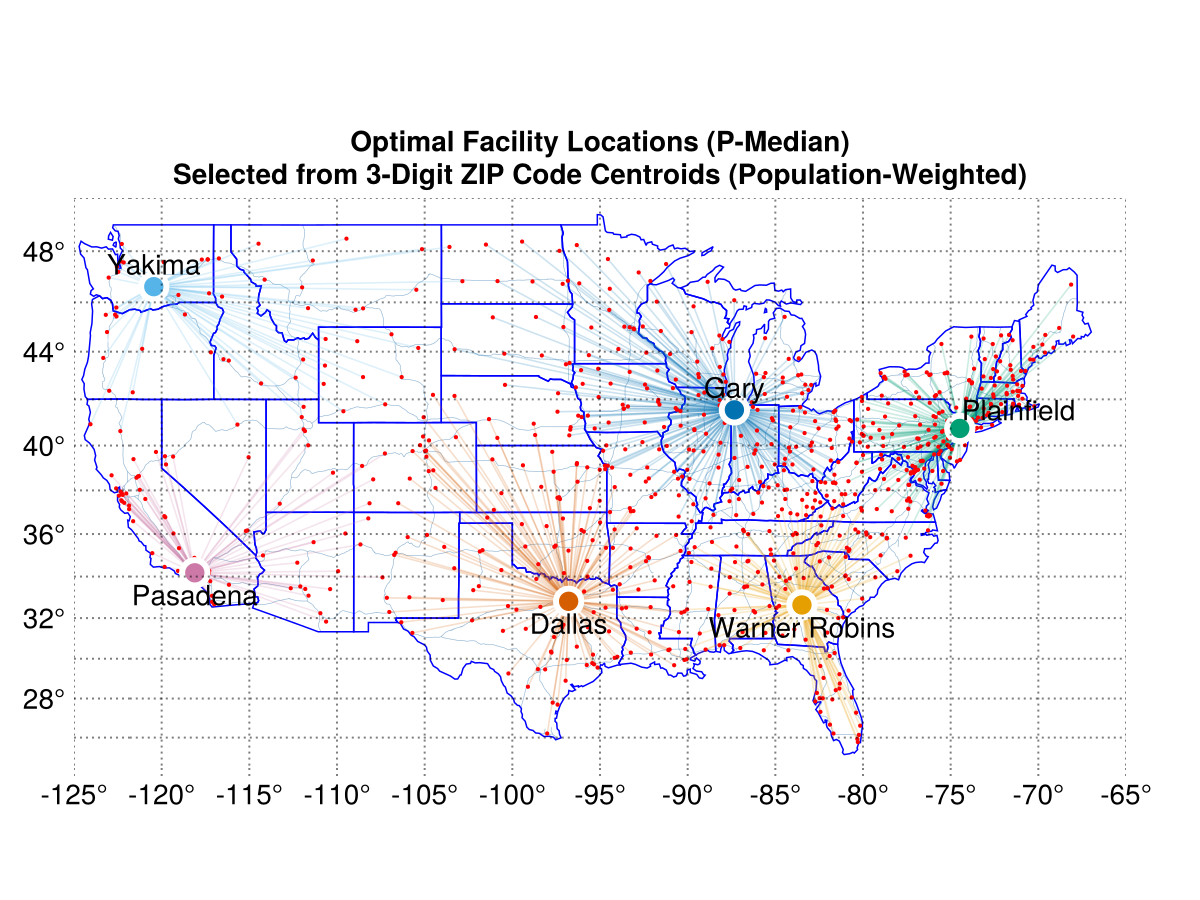

CairoMakie.Screen{IMAGE}


In [7]:
# Map: continental US with allocation lines and hub markers
fig, ax = makemap(region=:CUS)

colors = Makie.wong_colors()[1:6]
X, Y = alloclines(W, XY, XY)
for (ci, i) in enumerate(y)
    lines!(ax, X[i], Y[i], color=(colors[ci], 0.2), linewidth=0.8)
end

scatter!(ax, XY[:, 1], XY[:, 2], color=:red, markersize=3, strokewidth=0)
hub_xy = XY[y, :]
scatter!(ax, hub_xy[:, 1], hub_xy[:, 2], color=colors, markersize=18,
         strokewidth=3, strokecolor=:white)
text!(ax, hub_xy[:, 1], hub_xy[:, 2], text=hubs.name; aligntext(hub_xy[:, 1], hub_xy[:, 2])...)

ax.title = "Optimal Facility Locations (P-Median)\nSelected from 3-Digit ZIP Code Centroids (Population-Weighted)"
display(fig)

**After-action.** `dists(XY, XY, :mi)` computes a full pairwise great-circle distance matrix in miles; the `:mi` symbol selects miles, `:km` selects kilometers, and `:gc` returns dimensionless radians. Broadcasting `.* z3.POP'` weights each column by the destination's population, converting the distance matrix into a cost matrix in people-miles. `pmedian` returns the hub indices `y`, total cost `TC`, and the allocation matrix `W` (a sparse indicator mapping each demand point to its nearest hub). `alloclines` converts `W` into NaN-separated line segment vectors per hub, which `lines!` renders efficiently without a loop per connection. `lonlat2name` reverse-geocodes the hub coordinates to the nearest large city, providing interpretable labels. For problems where the number of facilities is itself a decision, Logjam provides UFL heuristics — `ufladd`, `ufldrop`, `uflxchg`, and `ufl` — that optimize both facility selection and count.

---

## Example 4 — Network Analysis and Vehicle Routing

Road network routing in Logjam uses the FAF5 national freight highway network as the foundation. The standard pipeline — `cropnetwork` → `addconnectors` → `links2graph` → `shortestpaths` — prepares a network for any routing task.

A pickup-delivery problem (PDP) is a routing problem where each shipment has a distinct origin and destination. This example routes five shipments across ten NC cities using the FAF5 highway network. The vehicle does not return to a starting depot — the route connects pickups and deliveries in the optimal sequence.

In [8]:
using Logjam
using GeoMakie, CairoMakie, DataFrames

# Load NC cities with population > 100,000
cities = filter(r -> r.STFIP == st2fips(:NC) && r.POP > 100_000, usplace())

Row,STFIP,PLFIP,NAME,ST,LAT,LON,POP,ALAND,AWATER,LSAD,FUNCSTAT,CBSA,ISCUS
,Int64,Int64,String,Symbol,Float64,Float64,Int64,Float64,Float64,String3,String1,Int64?,Bool
1,37,10740,Cary,NC,35.7814,-78.819,174721,59.233,1.083,43,A,39580,true
2,37,12000,Charlotte,NC,35.209,-80.831,874579,308.285,1.977,25,A,16740,true
3,37,14100,Concord,NC,35.3921,-80.6355,105240,63.479,0.035,25,A,16740,true
4,37,19000,Durham,NC,35.98,-78.901,283506,112.791,0.821,25,A,20500,true
5,37,22920,Fayetteville,NC,35.0828,-78.9735,208501,148.258,1.828,25,A,22180,true
6,37,28000,Greensboro,NC,36.0951,-79.827,299035,129.584,5.236,25,A,24660,true
7,37,31400,High Point,NC,35.9908,-79.9927,114059,56.365,1.523,25,A,24660,true
8,37,55000,Raleigh,NC,35.8302,-78.6415,467665,147.116,1.089,25,A,39580,true
9,37,74440,Wilmington,NC,34.2092,-77.8858,115451,51.405,1.564,25,A,48900,true


**City Index** (alphabetical order from `filter`):

| Index | City | | Index | City |
|:-----:|------|---|:-----:|------|
| 1 | Cary | | 6 | Greensboro |
| 2 | Charlotte | | 7 | High Point |
| 3 | Concord | | 8 | Raleigh |
| 4 | Durham | | 9 | Wilmington |
| 5 | Fayetteville | | 10 | Winston-Salem |

In [9]:
# Define 5 shipments with distinct origins and destinations
shipments = DataFrame(
    b = [2, 3, 10, 7, 6],   # Pickup city index
    e = [8, 4,  1, 5, 9]    # Delivery city index
)

Row,b,e
,Int64,Int64
1,2,8
2,3,4
3,10,1
4,7,5
5,6,9


**Shipment Manifest:**

| Shipment | Origin | Destination |
|:--------:|--------|-------------|
| 1 | Charlotte (2) | Raleigh (8) |
| 2 | Concord (3) | Durham (4) |
| 3 | Winston-Salem (10) | Cary (1) |
| 4 | High Point (7) | Fayetteville (5) |
| 5 | Greensboro (6) | Wilmington (9) |

In [10]:
# Build road network: crop FAF5 to region, attach city connectors
nodes_base, links_base = cropnetwork(faf5nodes(), faf5links(), cities.LON, cities.LAT)
nodes, links = addconnectors(nodes_base, links_base, cities.LON, cities.LAT)

# Compute shortest paths between all city connector nodes
g = links2graph(links)
dist_mat, parents = shortestpaths(g, nrow(cities))

# Construct route with savings heuristic, then improve with 2-opt
cost_fn(r) = rteTC(r, shipments, dist_mat)
initial_routes = savings(cost_fn, shipments)
final_route, cost = twoopt(initial_routes[1], cost_fn)
println("Route cost: $(round(cost; digits=2)) miles")

Route cost: 368.34 miles


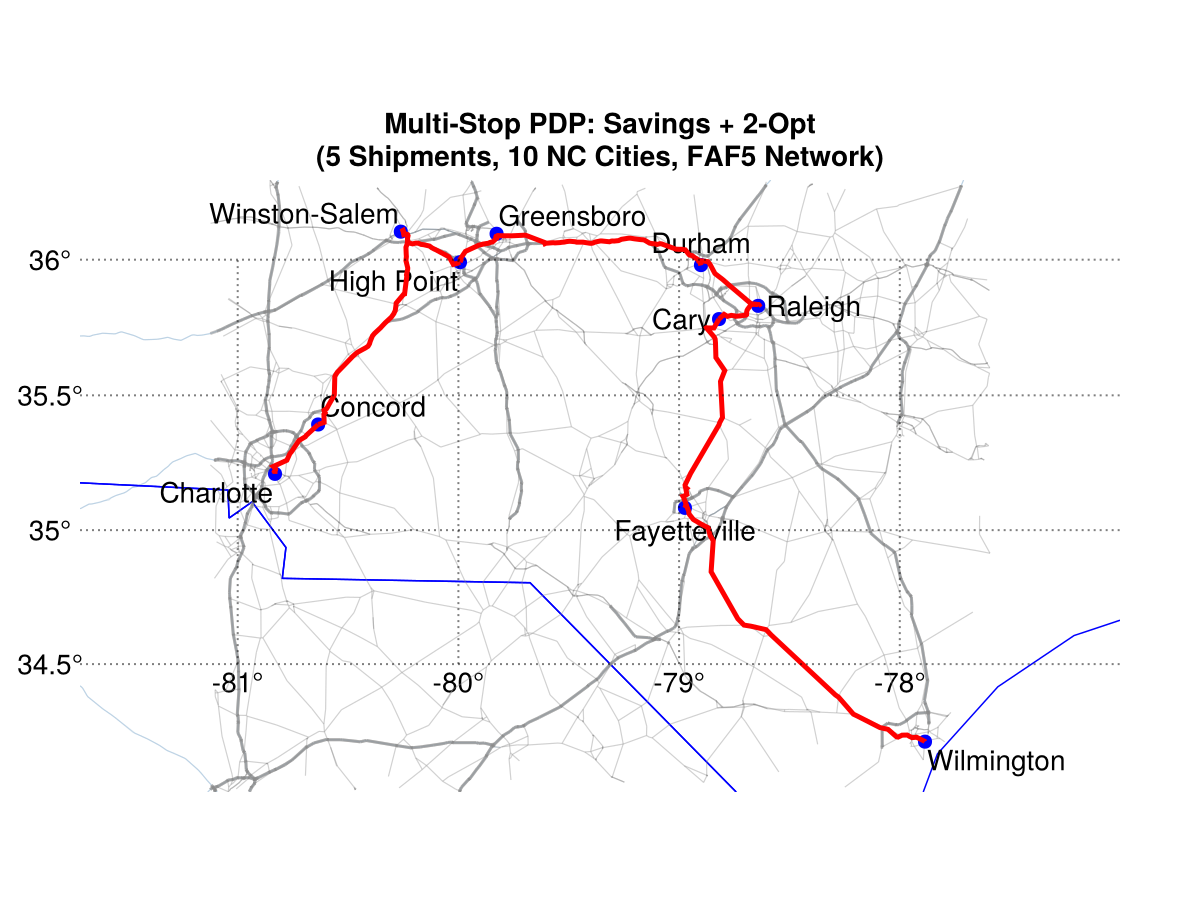

CairoMakie.Screen{IMAGE}


In [11]:
# Map: NC region with road network overlay and optimized route
fig, ax = makemap(cities.LON, cities.LAT)
plotroads!(ax, links, nodes)

scatter!(ax, cities.LON, cities.LAT, color=:blue, markersize=10)
text!(ax, cities.LON, cities.LAT, text=cities.NAME; aligntext(cities.LON, cities.LAT)...)

plotroute!(ax, final_route, shipments, parents, nodes; color=:red, linewidth=2.5, show_markers=false)

ax.title = "Multi-Stop PDP: Savings + 2-Opt\n(5 Shipments, 10 NC Cities, FAF5 Network)"
display(fig)

**After-action.** `cropnetwork` extracts the FAF5 subgraph whose bounding box contains the demand points, reducing graph size before solving. `addconnectors` appends artificial connector edges from each demand point to its nearest network node — without these, the demand points would not be reachable via shortest paths. `shortestpaths(g, nrow(cities))` computes shortest-path distances and parent pointers from the last `nrow(cities)` nodes (the connectors), returning a `dist_mat` ready for use as the routing cost matrix. `plotroads!` renders the road network with FCLASS-based styling inspired by OSM Carto — roads are colored and sized by functional class (interstates in muted blue, arterials in warm yellow, local roads in white/gray), with casings at close zoom for visual clarity. `savings` constructs an initial route by iteratively merging the most cost-saving shipment pair, then `twoopt` improves it by reversing sub-sequences. `plotroute!` handles the full rendering pipeline internally: it converts the abstract route to a stop sequence, reconstructs the road-following path for each leg from the parent pointer vectors, and renders the result.

---

## Example 5 — Vehicle Routing (OSM Network)

> **Requires OSM extension:** load `LightOSM` and `NearestNeighbors` before `Logjam`.

The `osm_roads` function downloads a local OpenStreetMap road network and integrates it with the same connector pipeline used for FAF5 routing. This example solves a capacitated multi-vehicle VRP in Gainesville, FL — three vehicles with a maximum of three deliveries each share nine stops from a central depot, with each vehicle returning after completing its route.

In [12]:
using LightOSM, NearestNeighbors  # Must precede Logjam to activate OSM extension
using Logjam
using GeoMakie, CairoMakie, DataFrames

# Download OSM road network for Gainesville urban core
bbox = (-82.365, -82.285, 29.620, 29.685)
nodes_osm, links_osm = osm_roads(bbox; cache_dir=joinpath(@__DIR__, "data"))

# Stop coordinates: stop 1 = depot (UF campus), stops 2–10 = deliveries
stops_lon = [-82.340, -82.360, -82.355, -82.348, -82.305, -82.298, -82.315, -82.340, -82.325, -82.350]
stops_lat = [ 29.650,  29.675,  29.668,  29.672,  29.662,  29.655,  29.670,  29.635,  29.630,  29.628]

# Build network and shortest paths
nodes, links = addconnectors(nodes_osm, links_osm, stops_lon, stops_lat; add_nf_nf=false)
g = links2graph(links)
dist_mat, parents = shortestpaths(g, length(stops_lon))

[ Info: Loading cached OSM data: c:\Users\kay\Documents\cdev\log\Logjam\examples\data\osm_w-82.4_e-82.25_s29.6_n29.7_nodes.csv


([0.0 3.020428894461312 … 2.0771388952559184 2.0886154322441497; 2.9761069954850097 0.0 … 4.95743795847921 4.061024827042552; … ; 2.0662713599827804 4.999431413550719 … 0.0 2.466054734049231; 2.0932517756873668 4.101968009978264 … 2.457094792119278 0.0], [[0, 9279, 781, 7392, 8203, 24111, 3505, 2208, 22676, 24813  …  27065, 13707, 6302, 11418, 9354, 608, 20078, 5775, 14050, 5568], [16651, 0, 9718, 23397, 8203, 24111, 3505, 2208, 22676, 24813  …  27065, 13707, 6302, 11418, 9354, 608, 20078, 5775, 14050, 5568], [16651, 9279, 0, 23397, 8203, 24111, 3505, 2208, 22676, 24813  …  27065, 13707, 6302, 11418, 9354, 608, 20078, 5775, 14050, 5568], [23651, 9279, 781, 0, 8203, 24111, 12760, 2208, 22676, 24813  …  27065, 13707, 6302, 11418, 9354, 608, 20078, 5775, 14050, 5568], [23651, 9279, 781, 7392, 0, 24111, 3505, 2208, 979, 24813  …  27065, 13707, 6302, 11418, 9354, 608, 20078, 5775, 14050, 795], [23651, 9279, 781, 7392, 26934, 0, 3505, 2208, 979, 24813  …  27065, 13707, 6302, 11418, 9354, 608

In [13]:
# VRP: all deliveries depart from depot (stop 1), max 3 per vehicle
shipments = DataFrame(b = fill(1, 9), e = 2:10)
tr = (b=[1], e=[1])
cost_fn(r) = length(r) > 6 ? Inf : rteTC(r, shipments, dist_mat, tr)

routes = savings(cost_fn, shipments)
routes = [twoopt(r, cost_fn)[1] for r in routes]
println(length(routes), " routes, ", [length(r)÷2 for r in routes], " stops each")

3 routes, [3, 3, 3] stops each


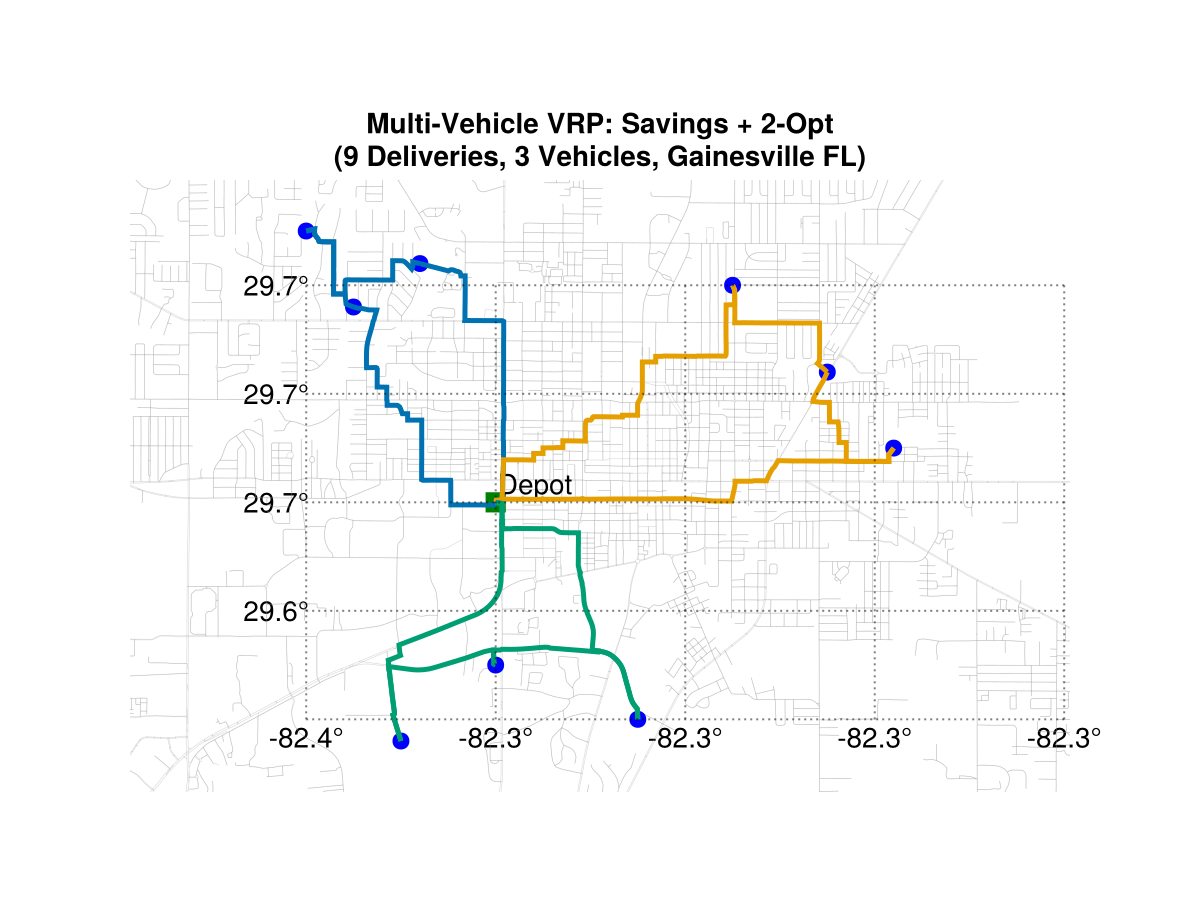

CairoMakie.Screen{IMAGE}


In [14]:
# Map: OSM road network with color-coded vehicle routes
fig, ax = makemap(stops_lon, stops_lat)
plotroads!(ax, links, nodes)

scatter!(ax, stops_lon[2:end], stops_lat[2:end], color=:blue, markersize=12)
scatter!(ax, [stops_lon[1]], [stops_lat[1]], color=:green, markersize=16, marker=:rect)
text!(ax, [stops_lon[1]], [stops_lat[1]], text=["Depot"]; aligntext([stops_lon[1]], [stops_lat[1]])...)

plotroute!(ax, routes, shipments, parents, nodes; tr=tr, linewidth=2.5, show_markers=false)

ax.title = "Multi-Vehicle VRP: Savings + 2-Opt\n(9 Deliveries, 3 Vehicles, Gainesville FL)"
display(fig)

**After-action.** `osm_roads` downloads drivable roads from the Overpass API and caches results as CSV files; subsequent calls with the same bbox load from cache. `add_nf_nf=false` disables direct demand-to-demand connectors that would bypass the road network — without this, nearby stops take straight-line shortcuts instead of following OSM roads. The capacity constraint is enforced through the cost function: `length(r) > 6 ? Inf : ...` limits each route to three deliveries (each shipment appears twice in the route as a pickup–delivery pair), causing `savings` to produce multiple routes rather than merging everything into a single tour. `tr=(b=[1], e=[1])` specifies that each route begins and ends at the depot. The multi-route `plotroute!` method accepts a `Vector{Vector{Int}}` and automatically assigns a distinct color per vehicle from the Wong color palette. For scenarios requiring local OSM detail integrated with the national FAF5 network, Logjam's `stitchnetworks` function creates connector edges between the two networks, returning a unified graph compatible with the standard routing pipeline.